In [ ]:
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import make_circles #Make circles is a binary classification dataset inbuilt in sklearn

## 7. Replicating non-linear activation functions

We saw before how adding non-linear activation functions to our model can help it to model non-linear data.

> **Note:** Much of the data you'll encounter in the wild is non-linear (or a combination of linear and non-linear). Right now we've been working with dots on a 2D plot. But imagine if you had images of plants you'd like to classify, there's a lot of different plant shapes. Or text from Wikipedia you'd like to summarize, there's lots of different ways words can be put together (linear and non-linear patterns).

But what does a non-linear activation *look* like?

How about we replicate some and what they do?

Let's start by creating a small amount of data.

In [ ]:
A = torch.arange(-10 , 10 , 1 , dtype = torch.float32)

In [ ]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

A straight line, nice.

Now let's see how the ReLU activation function influences it.A

And instead of using PyTorch's ReLU (`torch.nn.ReLU`), we'll recreate it ourselves.

The ReLU function turns all negatives to 0 and leaves the positive values as they are.

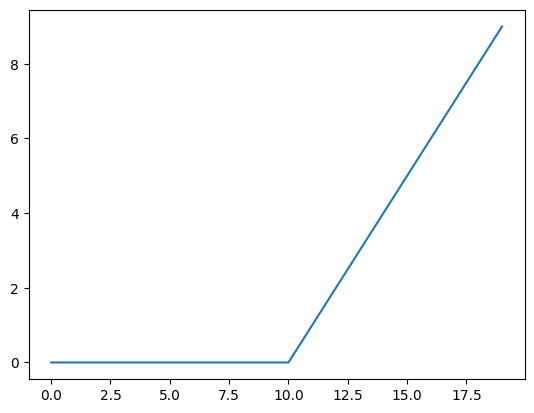

In [ ]:
plt.plot(torch.relu(A))

In [ ]:
def ReLU(x):
  return torch.max(torch.tensor(0),x)
ReLU(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

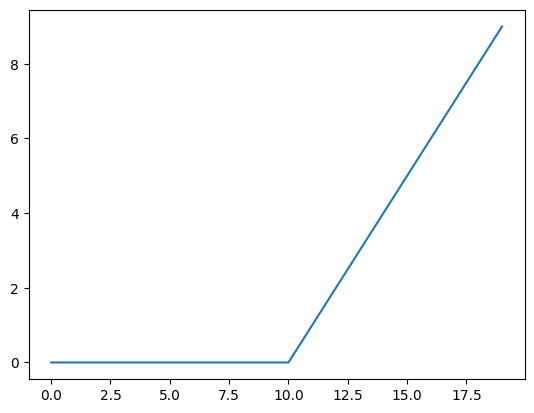

In [ ]:
plt.plot(ReLU(A));

Nice! That looks exactly like the shape of the ReLU function on the [Wikipedia page for ReLU](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)).

How about we try the [sigmoid function](https://en.wikipedia.org/wiki/Sigmoid_function) we've been using?

The sigmoid function formula goes like so:

$$ out_i = \frac{1}{1+e^{-input_i}} $$

Or using $x$ as input:

$$ S(x) = \frac{1}{1+e^{-x_i}} $$

Where $S$ stands for sigmoid, $e$ stands for [exponential](https://en.wikipedia.org/wiki/Exponential_function) ([`torch.exp()`](https://pytorch.org/docs/stable/generated/torch.exp.html)) and $i$ stands for a particular element in a tensor.

Let's build a function to replicate the sigmoid function with PyTorch.

In [ ]:
def Sigmoid(x):
  return 1/(1+torch.exp(-x))

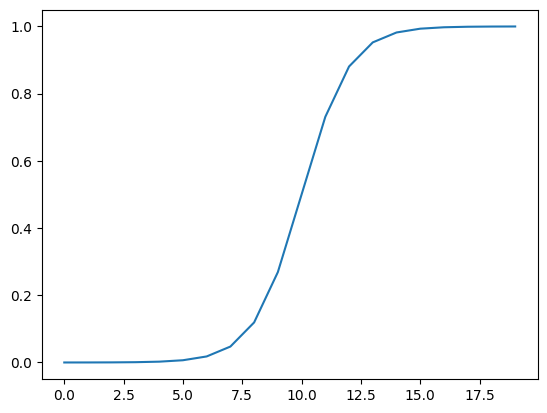

In [ ]:
plt.plot(Sigmoid(A));

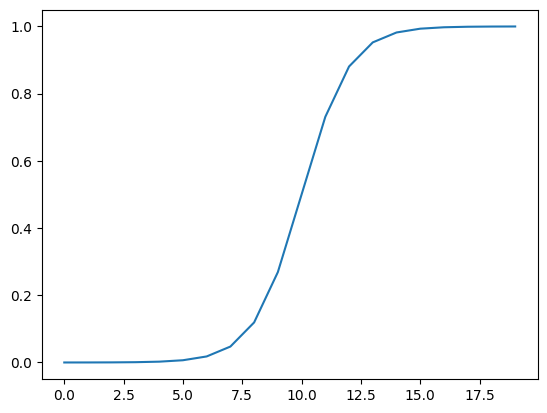

In [ ]:
plt.plot(torch.sigmoid(A));

## 8. Putting things together by building a multi-class PyTorch model

We've covered a fair bit.

But now let's put it all together using a multi-class classification problem.

Recall a **binary classification** problem deals with classifying something as one of two options (e.g. a photo as a cat photo or a dog photo) where as a **multi-class classification** problem deals with classifying something from a list of *more than* two options (e.g. classifying a photo as a cat a dog or a chicken).

puter vision benchmark and has 1000 classes.*


### 8.1 Creating multi-class classification data

To begin a multi-class classification problem, let's create some multi-class data.

To do so, we can leverage Scikit-Learn's [`make_blobs()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) method.

This method will create however many classes (using the `centers` parameter) we want.

Specifically, let's do the following:

1. Create some multi-class data with `make_blobs()`.
2. Turn the data into tensors (the default of `make_blobs()` is to use NumPy arrays).
3. Split the data into training and test sets using `train_test_split()`.
4. Visualize the data.

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [ ]:
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

In [ ]:
X_blob,y_blob = make_blobs(n_samples = 1000 ,
                           n_features = NUM_FEATURES,
                           centers=NUM_CLASSES,
                           cluster_std = 1.5,
                           random_state=RANDOM_SEED)

In [ ]:
X_blob.shape,y_blob.shape

((1000, 2), (1000,))

In [ ]:
X_blob = torch.from_numpy(X_blob).type(torch.float32)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

In [ ]:
X_blob_train , X_blob_test , y_blob_train , y_blob_test = train_test_split(X_blob,y_blob ,train_size=0.8 ,random_state=42 )

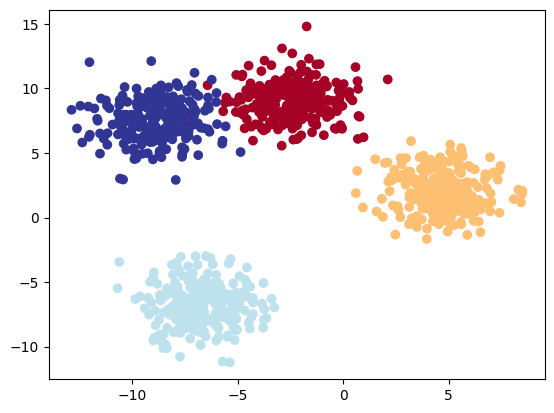

In [ ]:
plt.scatter(X_blob[:,0] , X_blob[:,1] , c = y_blob , cmap = 'RdYlBu')

In [ ]:
#Device Agnostic Code

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
class BlobModel(nn.Module):
  def __init__(self,in_features,out_features,hidden_layers = 8):
    super().__init__()
    self.linearstack = nn.Sequential(
        nn.Linear(in_features=in_features , out_features=hidden_layers),
        nn.ReLU(),
        nn.Linear(in_features=hidden_layers , out_features=hidden_layers),
        nn.ReLU(),
        nn.Linear(in_features=hidden_layers , out_features=out_features)
    )

  def forward(self , x):
    return self.linearstack(x)
Apna_MC_Model = BlobModel(in_features=2 , out_features=4).to(device)

In [ ]:
Apna_MC_Model

BlobModel(
  (linearstack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

Loss Functions and Optimizer

In [ ]:
loss = nn.CrossEntropyLoss()
optim = torch.optim.SGD(params = Apna_MC_Model.parameters() , lr = 0.01)

In [ ]:
Apna_MC_Model.eval()
with torch.inference_mode():
  y_logits = Apna_MC_Model(X_blob_test)
y_logits

tensor([[-5.7311e-03,  4.9412e-02,  1.9346e-01, -2.1437e-01],
        [-6.1703e-01,  1.1968e+00,  2.1289e+00, -7.4136e-01],
        [-2.3579e-01,  5.8918e-01,  1.2274e+00, -1.1140e+00],
        [ 6.4182e-02, -8.0491e-02,  3.2226e-01, -4.1079e-01],
        [-1.1660e-01,  1.2310e-01,  1.0855e+00, -5.0188e-01],
        [-7.1699e-01,  1.4221e+00,  2.5651e+00, -8.9119e-01],
        [-6.3444e-03, -1.1774e-02,  1.1845e+00, -1.6983e+00],
        [-3.3793e-01,  4.1951e-01,  1.1540e+00, -4.7509e-01],
        [-3.5848e-01,  1.2585e+00,  1.8151e+00, -7.6176e-01],
        [-2.6629e-01,  2.9445e-01,  1.0898e+00, -4.8686e-01],
        [-4.1089e-01,  5.8395e-01,  1.2571e+00, -4.7003e-01],
        [ 1.1706e-02,  1.6895e-02,  2.3126e-01, -2.6687e-01],
        [-1.9718e-01,  2.0935e-01,  1.1339e+00, -5.1454e-01],
        [-3.3800e-01,  3.9594e-01,  1.2754e+00, -5.3475e-01],
        [-3.1985e-01,  3.5155e-01,  1.3243e+00, -5.6976e-01],
        [-5.6707e-01,  1.0482e+00,  1.8712e+00, -6.4858e-01],
        

In [ ]:
y_Pred_Probs = torch.softmax(y_logits , dim =1)
y_logits[:5],y_Pred_Probs[:5]

(tensor([[-0.0057,  0.0494,  0.1935, -0.2144],
         [-0.6170,  1.1968,  2.1289, -0.7414],
         [-0.2358,  0.5892,  1.2274, -1.1140],
         [ 0.0642, -0.0805,  0.3223, -0.4108],
         [-0.1166,  0.1231,  1.0855, -0.5019]]),
 tensor([[0.2446, 0.2584, 0.2985, 0.1985],
         [0.0424, 0.2599, 0.6603, 0.0374],
         [0.1247, 0.2846, 0.5388, 0.0518],
         [0.2644, 0.2288, 0.3423, 0.1645],
         [0.1593, 0.2024, 0.5299, 0.1084]]))

These prediction probabilities are essentially saying how much the model *thinks* the target `X` sample (the input) maps to each class.

Since there's one value for each class in `y_pred_probs`, the index of the *highest* value is the class the model thinks the specific data sample *most* belongs to.

We can check which index has the highest value using `torch.argmax()`.

In [ ]:
y_Preds = torch.argmax(y_Pred_Probs , dim = 1)

You can see the output of `torch.argmax()` returns 3, so for the features (`X`) of the sample at index 0, the model is predicting that the most likely class value (`y`) is 3.

Of course, right now this is just random guessing so it's got a 25% chance of being right (since there's four classes). But we can improve those chances by training the model.

> **Note:** To summarize the above, a model's raw output is referred to as **logits**.
>
> For a multi-class classification problem, to turn the logits into **prediction probabilities**, you use the softmax activation function (`torch.softmax`).
>
> The index of the value with the highest **prediction probability** is the class number the model thinks is *most* likely given the input features for that sample (although this is a prediction, it doesn't mean it will be correct).

In [ ]:
def Accuracy(y_true , y_Pred):
  com = torch.eq(y_Pred,y_true).sum().item()
  return f'{(com/len(y_true))*100}%'

In [ ]:
Accuracy(y_blob_test , y_Preds)

'26.5%'

Training and Testing loop

In [ ]:
y_blob_train.dtype

torch.int64

In [ ]:
torch.manual_seed(42)
epochs = 1000
X_blob_train,X_blob_test = X_blob_train.to(device) , X_blob_test.to(device)
y_blob_test,y_blob_train =  y_blob_test.to(device) , y_blob_train.to(device)
for epoch in range(epochs):
  Apna_MC_Model.train()
  Train_Logits = Apna_MC_Model(X_blob_train)
  Train_Preds = torch.argmax(torch.softmax(Train_Logits , dim = 1) , dim = 1)

  Train_Loss = loss(Train_Logits, y_blob_train)
  Train_Accuracy = Accuracy(y_blob_train , Train_Preds)

  optim.zero_grad()
  Train_Loss.backward()
  optim.step()

  Apna_MC_Model.eval()
  with torch.inference_mode():
    Test_Logits = Apna_MC_Model(X_blob_test)
    Test_Preds = torch.softmax(Test_Logits , dim = 1).argmax(dim = 1)

    Test_Loss = loss(Test_Logits, y_blob_test)
    Test_Accuracy = Accuracy(y_blob_test , Test_Preds)

  if epoch%10==0:
    print(f'Epochs = {epoch} , Train_Loss = {Train_Loss} , Train Accuracy = {Train_Accuracy} , Test_Loss = {Test_Loss} , Test_Accuracy = {Test_Accuracy}')


Epochs = 0 , Train_Loss = 1.9813045263290405 , Train Accuracy = 24.625% , Test_Loss = 1.8872404098510742 , Test_Accuracy = 26.5%
Epochs = 10 , Train_Loss = 1.3182090520858765 , Train Accuracy = 24.625% , Test_Loss = 1.2394171953201294 , Test_Accuracy = 26.5%
Epochs = 20 , Train_Loss = 1.0994114875793457 , Train Accuracy = 51.87500000000001% , Test_Loss = 1.0202561616897583 , Test_Accuracy = 60.5%
Epochs = 30 , Train_Loss = 0.982422411441803 , Train Accuracy = 59.12500000000001% , Test_Loss = 0.9023241400718689 , Test_Accuracy = 64.5%
Epochs = 40 , Train_Loss = 0.8898673057556152 , Train Accuracy = 64.25% , Test_Loss = 0.8105278015136719 , Test_Accuracy = 72.5%
Epochs = 50 , Train_Loss = 0.8115431070327759 , Train Accuracy = 78.25% , Test_Loss = 0.733864426612854 , Test_Accuracy = 84.5%
Epochs = 60 , Train_Loss = 0.7438400387763977 , Train Accuracy = 82.625% , Test_Loss = 0.6681521534919739 , Test_Accuracy = 90.0%
Epochs = 70 , Train_Loss = 0.6854060888290405 , Train Accuracy = 88.25% ,

In [ ]:
import requests
from pathlib import Path
path = Path('helper_functions.py')
link = 'https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py'

if path.exists():
  print('Path exists')
else:
  print('Downloading it ')
  request = requests.get(link)
  with open('helper_function.py','wb') as file:
    file.write(request.content)
  print('Downloaded')


Downloaded


In [ ]:
from helper_function import plot_decision_boundary

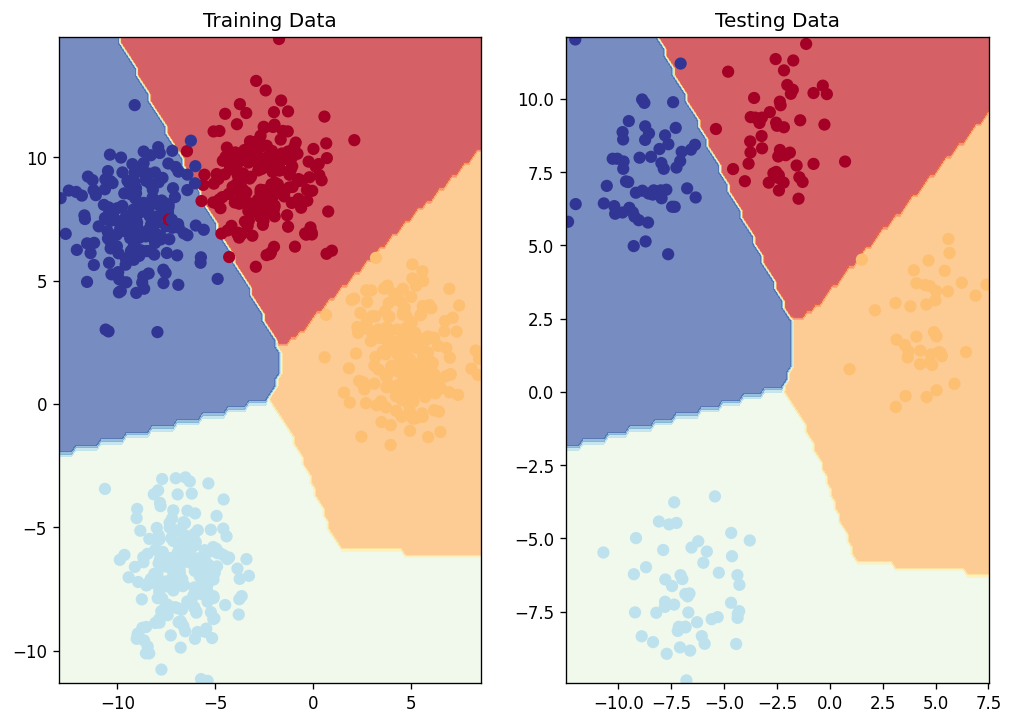

In [ ]:
plt.figure(figsize = (10,7) , dpi = 120)
plt.subplot(1,2,1)
plt.title('Training Data')
plot_decision_boundary(Apna_MC_Model , X_blob_train , y_blob_train)
plt.subplot(1,2,2)
plt.title('Testing Data')
plot_decision_boundary(Apna_MC_Model , X_blob_test , y_blob_test)

## 9. More classification evaluation metrics

So far we've only covered a couple of ways of evaluating a classification model (accuracy, loss and visualizing predictions).

These are some of the most common methods you'll come across and are a good starting point.

However, you may want to evaluate your classification model using more metrics such as the following:

| **Metric name/Evaluation method** | **Defintion** | **Code** |
| --- | --- | --- |
| Accuracy | Out of 100 predictions, how many does your model get correct? E.g. 95% accuracy means it gets 95/100 predictions correct. | [`torchmetrics.Accuracy()`](https://torchmetrics.readthedocs.io/en/stable/classification/accuracy.html#id3) or [`sklearn.metrics.accuracy_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) |
| Precision | Proportion of true positives over total number of samples. Higher precision leads to less false positives (model predicts 1 when it should've been 0). | [`torchmetrics.Precision()`](https://torchmetrics.readthedocs.io/en/stable/classification/precision.html#id4) or [`sklearn.metrics.precision_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html) |
| Recall | Proportion of true positives over total number of true positives and false negatives (model predicts 0 when it should've been 1). Higher recall leads to less false negatives. | [`torchmetrics.Recall()`](https://torchmetrics.readthedocs.io/en/stable/classification/recall.html#id5) or [`sklearn.metrics.recall_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html) |
| F1-score | Combines precision and recall into one metric. 1 is best, 0 is worst. | [`torchmetrics.F1Score()`](https://torchmetrics.readthedocs.io/en/stable/classification/f1_score.html#f1score) or [`sklearn.metrics.f1_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) |
| [Confusion matrix](https://www.dataschool.io/simple-guide-to-confusion-matrix-terminology/)  | Compares the predicted values with the true values in a tabular way, if 100% correct, all values in the matrix will be top left to bottom right (diagnol line). | [`torchmetrics.ConfusionMatrix`](https://torchmetrics.readthedocs.io/en/stable/classification/confusion_matrix.html#confusionmatrix) or [`sklearn.metrics.plot_confusion_matrix()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_predictions) |
| Classification report | Collection of some of the main classification metrics such as precision, recall and f1-score. | [`sklearn.metrics.classification_report()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) |

Scikit-Learn (a popular and world-class machine learning library) has many implementations of the above metrics and you're looking for a PyTorch-like version, check out [TorchMetrics](https://torchmetrics.readthedocs.io/en/latest/), especially the [TorchMetrics classification section](https://torchmetrics.readthedocs.io/en/stable/pages/classification.html).

Let's try the `torchmetrics.Accuracy` metric out.




In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
import torchmetrics
from torchmetrics import Accuracy

In [ ]:
torchmetrics_accuracy = Accuracy(task="multiclass", num_classes=4)
torchmetrics_accuracy(Test_Logits,y_blob_test)

tensor(0.9950)